In [10]:
import pandas as pd # for reading the data
import numpy as np # for data manipulation
import scipy.optimize as opt # for optimization
import matplotlib.pyplot as plt

### Exercise 01 - Local Regression
**Jenny Laberg Nilsson**  
**BERN02 - 2026/09**

**Project:** Fit a local regression over each point X0 =[10,18,25]  
**X0**: This is the targeted test point  
**k:** The number of points in the training data that are closest to the test point (X0)   
**Quantity of interest:** Mortality rate as a function of income (MORT vs. POOR)  
**Predictors:** POOR - (% of families with income < $3000)  
**Response:** MORT - (Total age-adjusted mortality rate per 100,000)   
**Model:** Local regression    

In [11]:
# Load pollution data
pollution_df = pd.read_csv("../data/pollution_cleaneddata.csv", encoding='utf-8')
# print the first 5 rows of the dataframe for a quick check of the data
pollution_df.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


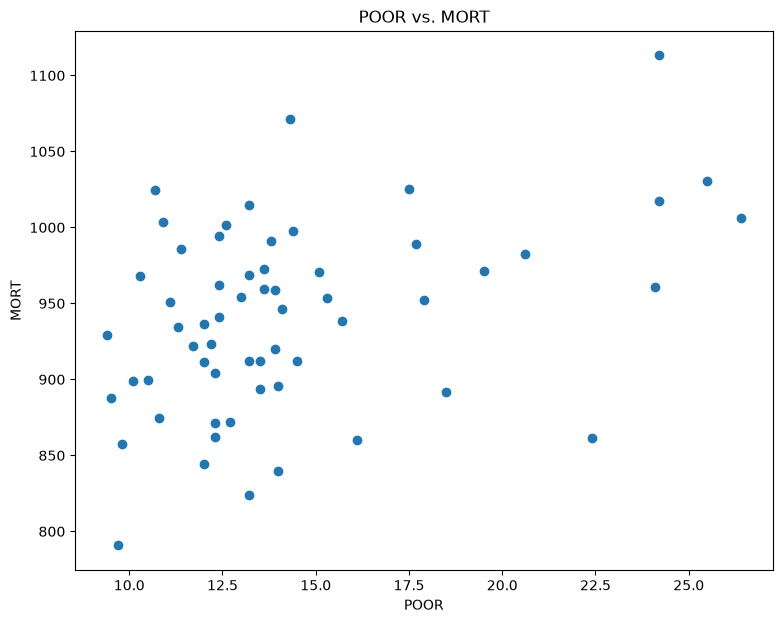

In [12]:
# first plot the data without any adjustments
plt.figure(figsize=(9,7))
plt.title("POOR vs. MORT")
plt.scatter(pollution_df['POOR'], pollution_df['MORT'], marker = 'o')
plt.xlabel('POOR')
plt.ylabel('MORT')
plt.show()

In [13]:
def local_x(x, y, x0, k):
    """
    Find the closest points to x0 by calculating the squared distance between each point in x and x0.
    k is the number of x closest points to x0 to return.
    The function returns a list of tuples containing the squared distance and the x and y coordinates for the k closest points.
    """
    # make a empty list for storing the squared distances between each point in x and x0 and the coordinates of the points in x and y
    squared_distances_list = []
    # loop through each point in x and calculate the squared distance between the point and x0
    for i in range(len(x)):
        x_val = float(x.iloc[i])
        y_val = float(y.iloc[i])
        squared_distance = float((x_val - x0) ** 2)
        squared_distances_list.append((squared_distance, x_val, y_val))
    # sort list by the squared distances so that the closest points are at the beginning of the list
    squared_distances_list.sort()
    # return the k closest points
    return squared_distances_list[:k]


In [14]:
def optimize_sum_of_squares(beta, x_closest, y_closest, weights):
    """
    Find the optimal beta parameters for the weighted linear regression model by minimizing the sum of squares.
    """
    beta_0 = beta[0]
    beta_1 = beta[1]

    # calculate the sum of squares
    eq = weights * (y_closest - (beta_0 + beta_1 * x_closest)) ** 2
    return(eq.sum())

In [15]:
def weight_function(x_closest, x0):
    """
    This function calculate the weight for each point in x
    I have decided to use the inverse distance weighting (IDW) scheme as my weight function.
    distance = x_i - x_0
    weight = 1 / distance
    
    """
    # compute the physical distance on the x-axis for each local point
    distances = np.abs(x_closest - x0)    
    # compute the weight
    weights = 1 / (distances)
    return weights

In [16]:
def local_regression(x, y, x0, k):
    """
    Perform local regression on the data using the k closest points to x0. 
    Returns:
      - y_0: predicted expected value at x0
      - rse: standard deviation of residuals (Residual Standard Error)
      - se_y_hat: standard error of the expected value E[Y|x0]
    """
    # allows x0 to be a list or array and returns a list of predicted values for each value in x0
    if isinstance(x0, (list, np.ndarray)):
        return [local_regression(x, y, val, k) for val in x0]
        
    # get the closest points
    closest_points = local_x(x, y, x0, k)

    x_closest = np.array([point[1] for point in closest_points])
    y_closest = np.array([point[2] for point in closest_points])

    weights = weight_function(x_closest, x0)

    # fit local model
    beta = opt.minimize(optimize_sum_of_squares, [0, 0], args=(x_closest, y_closest, weights)).x
    beta_0 = beta[0]
    beta_1 = beta[1]

    # predict expected value (y_0) at x0
    y_0 = beta_0 + beta_1 * x0

    # === Calculations from lecture slides (without the weight included) ===
    n = len(x_closest) # sample size
    residuals = y_closest - (beta_0 + beta_1 * x_closest)
    df = n - 2
    
    # residual variance (sigma_sqr) and RSE
    sigma_sqr = np.sum(residuals ** 2) / df
    rse = np.sqrt(sigma_sqr)

    x_bar = np.mean(x_closest)
    ss_x = np.sum((x_closest - x_bar) ** 2)

    # slope variance V(beta_1)
    var_beta_1 = sigma_sqr / ss_x
    se_beta_1 = np.sqrt(var_beta_1)

    lambda_alpha = 2.0  
    margin_of_error = lambda_alpha * se_beta_1
    ci_lower_beta_1 = beta_1 - margin_of_error
    ci_upper_beta_1 = beta_1 + margin_of_error

    # Print slope diagnostics
    print(f"Target x0={x0} | Slope (beta_1): {beta_1:.4f} | 95% CI: [{ci_lower_beta_1:.4f}, {ci_upper_beta_1:.4f}]")

    # variance of expected value V(mu_hat(x0))
    var_expected_value = sigma_sqr * ((1 / n) + (((x0 - x_bar) ** 2) / ss_x))
    se_y_hat = np.sqrt(var_expected_value)

    # Return prediction, residual scatter (RSE), and standard error for error bars (se_y_hat)
    return float(y_0), float(rse), float(se_y_hat)

Target x0=10 | Slope (beta_1): 27.7551 | 95% CI: [5.0551, 50.4550]
Target x0=18 | Slope (beta_1): 2.3301 | 95% CI: [-7.6203, 12.2806]
Target x0=25 | Slope (beta_1): 8.2212 | 95% CI: [2.1801, 14.2624]


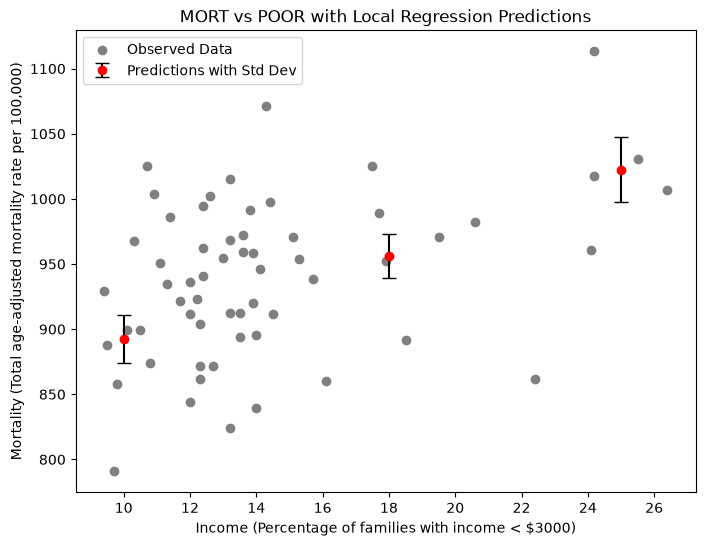

   x0  Predicted y  Standard Error
0  10   892.374470       18.654090
1  18   956.340470       17.038236
2  25  1022.547927       24.838085


In [17]:
# Output the predicted value of y at x0 and the standard deviation of the residuals for each x0 in X0
# Also plot the data with the predicted values and the standard deviation of the residuals as error bars

# choosen x0 values to predict and set k value to 5
X0 =[10,18,25]
k_val = 25

# call the local_regression function 
results = local_regression(pollution_df['POOR'], pollution_df['MORT'], X0, k_val)

# get the predicted values, standard deviations and standard errors for predictions
predictions = [result[0] for result in results]
rse = [result[1] for result in results]
se_y_hat = [result[2] for result in results]


# Plot the data with the predicted values and the standard deviation of the residuals as error bars
plt.figure(figsize=(8,6))
plt.title("MORT vs POOR with Local Regression Predictions")
plt.scatter(pollution_df['POOR'], pollution_df['MORT'], label='Observed Data', color='gray')
# set the x axis to be only whole numbers
plt.xticks(np.arange(0, 31, 2))
plt.errorbar(X0, predictions, yerr=se_y_hat, fmt='o', color='red', ecolor='black', capsize=5, label='Predictions with Std Dev')
plt.xlabel("Income (Percentage of families with income < $3000)")
plt.ylabel("Mortality (Total age-adjusted mortality rate per 100,000)")
plt.legend()
plt.show()

# Print the predicted values and standard deviations for each x0 in X0 as a table
results_df = pd.DataFrame({'x0': X0, 'Predicted y': predictions, 'Standard Error': se_y_hat})
print(results_df)
